In [ ]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append('tracking/tracking_utils/')
from tracking.tracking_utils.loader import create_trk_dataloaders
train_loader, val_loader, _ = create_trk_dataloaders(train_path='/home/sholtzen/torch-tracking/data/DynamicNuclearNet-tracking-v1_0/train.zarr',
                                                        val_path='/home/sholtzen/torch-tracking/data/DynamicNuclearNet-tracking-v1_0/val.zarr',
                                                        batch_size=4,
                                                        distance_threshold=64,
                                                        augment=True,
                                                        num_workers=4)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading /home/sholtzen/torch-tracking/data/DynamicNuclearNet-tracking-v1_0/train.zarr...


100%|██████████| 4/4 [00:02<00:00,  1.98it/s]


46


100%|██████████| 4/4 [00:02<00:00,  1.81it/s]


  X shape: (4, 71, 584, 600, 1)
  y shape: (4, 71, 584, 600, 1)
  Lineages: 4
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too 

100%|██████████| 4/4 [00:03<00:00,  1.27it/s]


87


100%|██████████| 4/4 [00:03<00:00,  1.16it/s]

  X shape: (4, 71, 584, 600, 1)
  y shape: (4, 71, 584, 600, 1)
  Lineages: 4
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too short in batch 0, skipping.
slice too 

: 

torch.Size([7, 87, 87, 3])
torch.Size([7, 87, 87, 3])
torch.Size([7, 87, 87, 3])
torch.Size([7, 87, 87, 3])


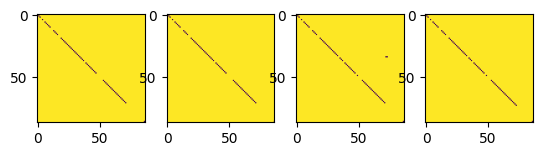

In [47]:
import matplotlib.pyplot as plt

# data_iterator = iter(val_loader)
data = next(data_iterator)
fig, ax = plt.subplots(1, 4)

for batch_idx in range(4):


    print(data['labels'][batch_idx].shape)

    ax[batch_idx].imshow(data['labels'][batch_idx,0,...,1])


In [6]:
import sys

sys.path.append('tracking/tracking_utils/')
from tracking.tracking_utils.model import GNNTrackingModel
import torch
from torch.nn import init

from tracking.tracking_utils.weight_initialization import init_weights_xavier_uniform



device = torch.device('cuda:6')

model = GNNTrackingModel(
                            graph_layer='gat', 
                            data_format='channels_last',
                            encoder_dim=64
                            )

model.to(device)

appearances = data['appearances'].to(device)
morphologies = data['morphologies'].to(device)
centroids = data['centroids'].to(device)
adj_matrices = data['adj_matrices'].to(device)
labels = data['labels'].to(device)

with torch.no_grad():
    predictions = model.training_forward(
    appearances, morphologies, centroids, adj_matrices,
    return_logits=False
    ).cpu()



In [19]:
import sys

sys.path.append('tracking/tracking_utils/')

from torch.optim import RAdam
from torch.optim.lr_scheduler import ExponentialLR, ChainedScheduler, StepLR
lr = 0.0001

from tracking.tracking_utils.model import GNNTrackingModel

model = GNNTrackingModel(
                            graph_layer='gat', 
                            data_format='channels_last',
                            encoder_dim=64
                            )
optimizer = RAdam(params=model.parameters())
scheduler = ChainedScheduler([
    ExponentialLR(optimizer, gamma=0.95),
    StepLR(optimizer=optimizer, step_size=10, gamma=0.1)
])

lrs = []
for epoch in range(100):
    lrs.append(scheduler.get_last_lr())
    optimizer.step()
    scheduler.step()


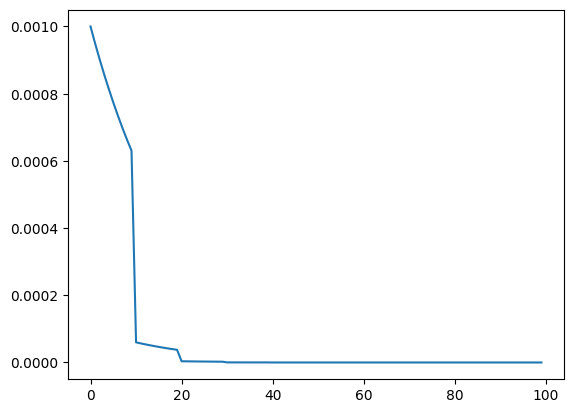

In [18]:
import matplotlib.pyplot as plt

plt.plot(range(100), lrs)